In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

# Set the visual parameters
sc.settings.set_figure_params(
    dpi = 200,
    facecolor='white',
    frameon=False
)

In [2]:
adata = sc.read_h5ad("../../data/figure-inputs/scrna_objects/final-bmmc-processed.h5ad")

In [3]:
celltypes = ["HSPC Stem", "LMPP", "CLP", "Prog B Pre", "Prog B",
             "CMP Core", "MEP", "Pre Prog Ery", "Pre Mono Core", "Prog DC cDC", "Prog DC pDC"]
celltypes_ordered = sorted(celltypes)
visit_keep = ["Healthy", "PreTx"]

adata_sub = adata[
    adata.obs["aifi_plot_l3"].isin(celltypes) & adata.obs["label.visitDetails"].isin(visit_keep)
].copy()


adata_sub.obs["group"] = (
    adata_sub.obs["aifi_plot_l3"].astype(str) + "_" + adata_sub.obs["label.visitDetails"].astype(str)
)

group_order = [
    f"{ct}_{v}" for ct in celltypes_ordered for v in visit_keep
    if f"{ct}_{v}" in adata_sub.obs["group"].values
]
adata_sub.obs["group"] = adata_sub.obs["group"].astype("category").cat.set_categories(group_order, ordered=True)

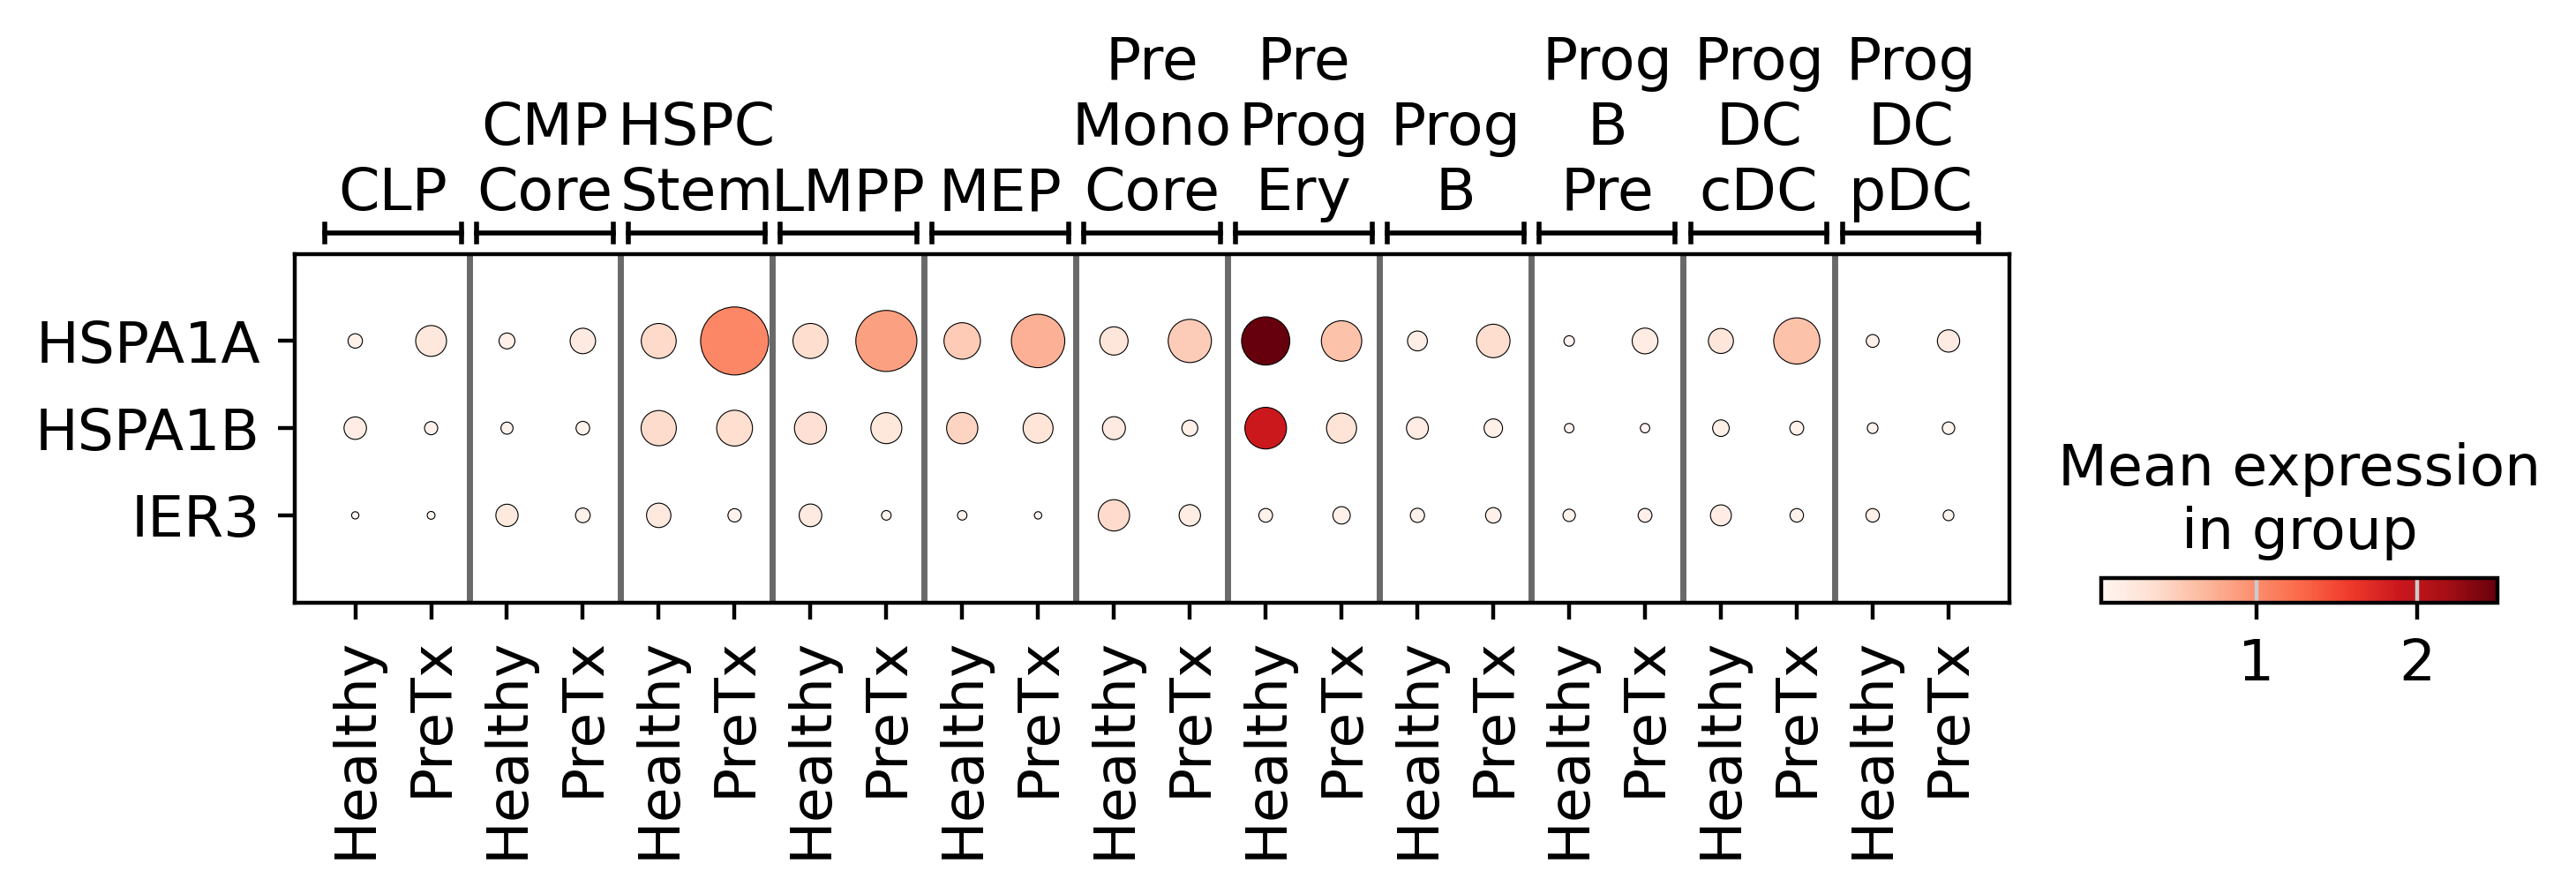

In [9]:
genes = ["HSPA1A", "HSPA1B", "IER3"]


plt.rcParams["pdf.fonttype"] = 42
dp = sc.pl.dotplot(adata_sub, var_names=genes, groupby="group", dendrogram=False, vmax=2.5,
                   swap_axes=True, show=False, figsize=(8, 1.3))
ax = dp["mainplot_ax"]
fig = ax.get_figure()
fig.canvas.draw()
for key in ["size_legend_ax"]:
    if key in dp:
        dp[key].set_visible(False)

xtick_positions = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
# Strip cell type prefix → show only visit name on x-axis
new_labels = []
for label in xticklabels:
    visit = next((v for v in visit_keep if label.endswith("_" + v)), None)
    new_labels.append(visit if visit else label)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(new_labels)
# Group x-tick positions by cell type
ct_tick_positions = {}
ct_order = []
for pos, label in zip(xtick_positions, xticklabels):
    if not label:
        continue
    ct = None
    for v in visit_keep:
        if label.endswith("_" + v):
            ct = label[:-(len(v) + 1)]
            break
    if ct is None:
        continue
    if ct not in ct_tick_positions:
        ct_tick_positions[ct] = []
        ct_order.append(ct)
    ct_tick_positions[ct].append(pos)
# Blended transform: x in data coords, y in axes-fraction coords
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
y_bracket = 1.06
y_text = 1.11
tick_h = 0.025
half = 0.4
prev_x1 = None
for ct in ct_order:
    positions = ct_tick_positions[ct]
    x0 = min(positions) - half
    x1 = max(positions) + half
    xm = (x0 + x1) / 2
    # Vertical separator line between cell type groups
    if prev_x1 is not None:
        xsep = (prev_x1 + x0) / 2
        ax.axvline(x=xsep, color="dimgray", lw=1.25, linestyle="-", zorder=0)
    prev_x1 = x1
    # Wrap label: one word per row
    words = ct.split()
    display_label = "\n".join(words)
    y_text_ct = 1.09
    # horizontal bar
    ax.plot([x0, x1], [y_bracket, y_bracket],
            transform=trans, color="black", lw=1, clip_on=False)
    # left cap
    ax.plot([x0, x0], [y_bracket - tick_h, y_bracket + tick_h],
            transform=trans, color="black", lw=1, clip_on=False)
    # right cap
    ax.plot([x1, x1], [y_bracket - tick_h, y_bracket + tick_h],
            transform=trans, color="black", lw=1, clip_on=False)
    # cell-type label
    ax.text(xm, y_text_ct, display_label,
            transform=trans, ha="center", va="bottom",
            fontsize=12, clip_on=False, linespacing=1.2)
    
plt.savefig("../../data/figure-outputs/supplementary-4/sup_4g.pdf", dpi=200, bbox_inches="tight")